# 📚 Phishing Email Detection using BERT - Project Notebook

## 📌 Table of Contents

1. [Project Overview](#project-overview)
2. [Environment Setup](#environment-setup)
3. [Data Loading and Sampling](#data-loading-and-sampling)
4. [Exploratory Data Analysis (EDA)](#exploratory-data-analysis-eda)
    - [Label Distribution](#label-distribution)
    - [Text Length Analysis](#text-length-analysis)
    - [Special Characters & URL Analysis](#special-characters--url-analysis)
    - [Top Words in Phishing Emails](#top-words-in-phishing-emails)
5. [Data Preprocessing](#data-preprocessing)
    - [Lowercasing](#lowercasing)
    - [Stopwords Removal (Optional)](#stopwords-removal-optional)
6. [Train-Validation-Test Split (70/10/20)](#train-validation-test-split-701020)
7. [Tokenization using BERT Tokenizer](#tokenization-using-bert-tokenizer)
8. [Dataset Preparation for PyTorch](#dataset-preparation-for-pytorch)
9. [Model Setup with BERT](#model-setup-with-bert)
10. [Define Training Arguments](#define-training-arguments)
11. [Trainer Setup and Metrics](#trainer-setup-and-metrics)
12. [Model Training](#model-training)
13. [Evaluate on Validation Set](#evaluate-on-validation-set)
14. [Evaluate on Test Set](#evaluate-on-test-set)
    - [Accuracy, Precision, Recall, F1-Score](#accuracy-precision-recall-f1-score)
    - [Confusion Matrix](#confusion-matrix)
15. [Plot Metrics (Accuracy/Loss vs Epoch)](#plot-metrics-accuracyloss-vs-epoch)
16. [Saving the Model and Tokenizer](#saving-the-model-and-tokenizer)
17
18. [Load Trained Model for Inference](#load-trained-model-for-inference)
19. [Next Steps and Improvements](#next-steps-and-improvements)


## Project overview
With the rapid rise of AI-generated content, phishing emails have become more sophisticated and harder to detect through traditional methods. Attackers now craft deceptive messages that closely mimic legitimate communication, putting individuals and organizations at risk of data theft, financial fraud, and identity compromise. This project aims to address the growing threat by developing an intelligent phishing email detection system using BERT, a powerful transformer-based language model. By analyzing the textual content of emails, our model learns to distinguish between phishing and legitimate messages with high accuracy, helping to automate and enhance email security on a large scale.

In [1]:
# import os
# os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"   # Apple GPU: fall back to CPU for any unsupported op

import pandas as pd
import re
import torch

#libraries for data explore
import seaborn as sns
import matplotlib.pyplot as plt

#libraries for Model training and evaluation
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, BertForSequenceClassification, AutoTokenizer
from transformers import Trainer, TrainingArguments
from transformers import DataCollatorWithPadding
from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support


In [2]:
# Example: Load a CSV dataset
df = pd.read_csv("phishing_email.csv")


df.shape

(82486, 2)

In [3]:
# Using the FULL dataset (no sampling)
print(df.head())


                                       text_combined  label
0  hpl nom may 25 2001 see attached file hplno 52...      0
1  nom actual vols 24 th forwarded sabrae zajac h...      0
2  enron actuals march 30 april 1 201 estimated a...      0
3  hpl nom may 30 2001 see attached file hplno 53...      0
4  hpl nom june 1 2001 see attached file hplno 60...      0


## Preprocess the Data

- **Remove null**
- **Lowercasing** : BERT handles case, but lowercase helps traditional models


# Preprocessing Steps Not Applied (with Justifications)

- **Remove URLs** : URLs are strong indicators of phishing, so we keep them as features.
- **Remove special characters** : Symbols like @, !, $, etc., are commonly used in phishing tactics and should be retained.
- **Remove punctuation** : Punctuation may be part of deceptive formatting or URLs, so we do not remove it.
- **Remove numbers** : Numbers (like fake invoice IDs or OTPs) may signal phishing intent, so we preserve them.
- **Remove stopwords** : Common words may carry phishing signals in certain contexts, so we keep them for now.
- **Remove capital letters** : Capitalization (e.g., “URGENT”) often indicates phishing, so we retain letter casing.
- **Stemming or Lemmatization** : We keep words in their original form to preserve possible phishing-related phrasing.
- **Remove HTML tags** : Some phishing emails use HTML tricks; we want to analyze them if present.
- **Spelling correction** : Typos and misspellings may be deliberate in phishing emails, so we avoid correcting them.



In [5]:
# Remove nulls
df.dropna(inplace=True)

df['label'] = df['label'].astype(int)

# Lowercasing only
def clean_text(text):
    return text.lower()

df['text_combined'] = df['text_combined'].apply(clean_text)



In [6]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 82486 entries, 0 to 82485
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   text_combined  82486 non-null  str  
 1   label          82486 non-null  int64
dtypes: int64(1), str(1)
memory usage: 102.7 MB
None


In [28]:
df.shape
print("duplicate texts:", df.duplicated('text_combined').sum())
df = df.drop_duplicates(subset='text_combined').reset_index(drop=True)

duplicate texts: 408


In [29]:
df.tail()

,text_combined,label,special_chars
82073,info advantageapartmentscom infoadvantageapart...,1,34
82074,monkeyorg helpdeskmonkeyorg monkeyorg hi josep...,1,0
82075,help center infohelpcentercoza_infohelpcenterc...,1,2
82076,metamask infosofamekarcom verify metamask wall...,1,0
82077,fastway infofastwaycoza_infofastwaycoza_infofa...,1,2


# Explore the dataset

#### Plot Class Distribution

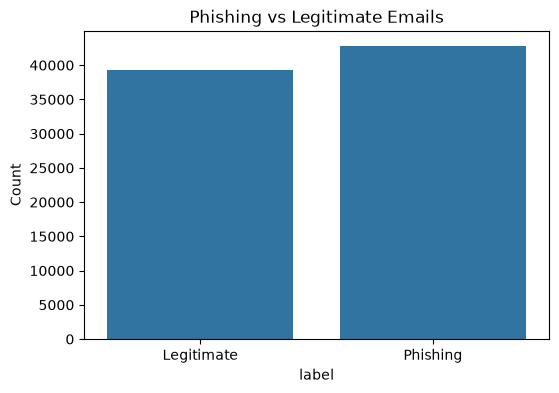

In [30]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='label') # counts the number of occurrences of each unique value in a column
plt.title('Phishing vs Legitimate Emails')
plt.xticks([0, 1], ['Legitimate', 'Phishing'])
plt.ylabel('Count')
plt.show()


#### Email/Text special character Length Distribution by Class
This graph is a boxplot comparing the number of special characters used in legitimate vs phishing emails.

Special characters: ! @ # $ % ^ & * ( ) _ + = { } [ ] : ; " ' < > / ? , . ~ etc.


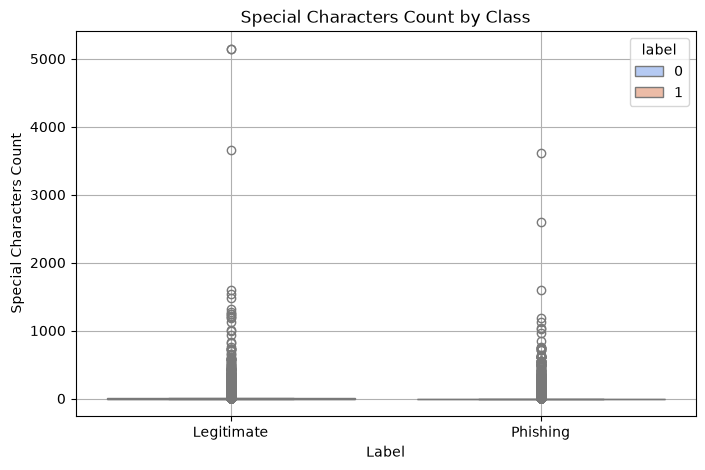

In [31]:
df['special_chars'] = df['text_combined'].apply(lambda x: sum(not c.isalnum() and not c.isspace() for c in x))

plt.figure(figsize=(8,5))
sns.boxplot(x='label', y='special_chars', data=df, hue='label', palette='coolwarm', dodge=False)

plt.xticks([0, 1], ['Legitimate', 'Phishing'])
plt.title('Special Characters Count by Class')
plt.xlabel('Label')
plt.ylabel('Special Characters Count')
plt.grid(True)
plt.show()


#### Most Common Words

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/chandrachhetri/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


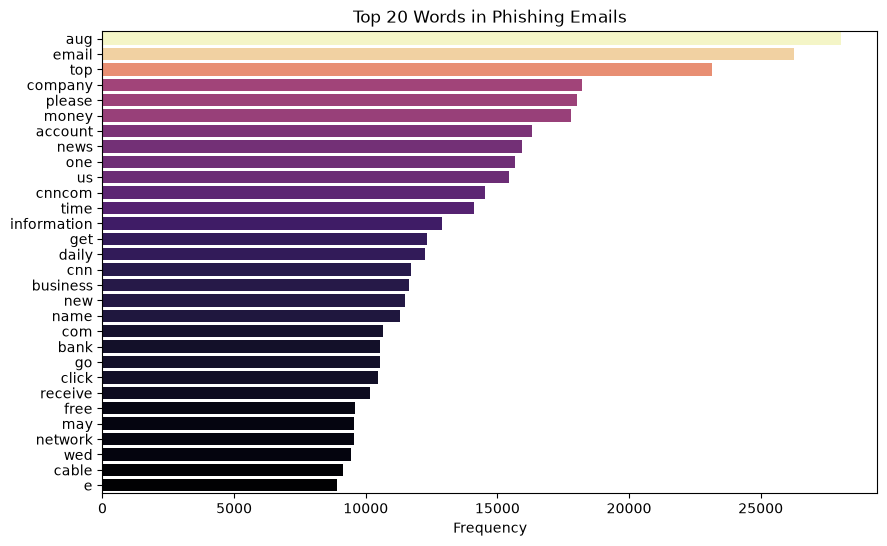

In [32]:
from collections import Counter
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')


stop_words = set(stopwords.words('english'))  #e.g., "the", "is", "and"

# Combine all phishing emails: Joins all texts into one string → converts to lowercase → splits into words
phishing_words = ' '.join(df[df['label']==1]['text_combined']).lower().split() #Selects only phishing emails (where label == 1)

filtered_words = [word for word in phishing_words if word.isalpha() and word not in stop_words] #Alphabetic words (removes numbers, punctuation)

word_freq = Counter(filtered_words).most_common(30)

# Barplot of top words
words, counts = zip(*word_freq)  #Unpacks the 20 most common word–count pairs into two separate lists: words and counts
plt.figure(figsize=(10,6))
sns.barplot(x=list(counts), y=list(words),hue =list(counts), palette='magma',legend=False)
plt.title('Top 20 Words in Phishing Emails')
plt.xlabel('Frequency')
plt.show()



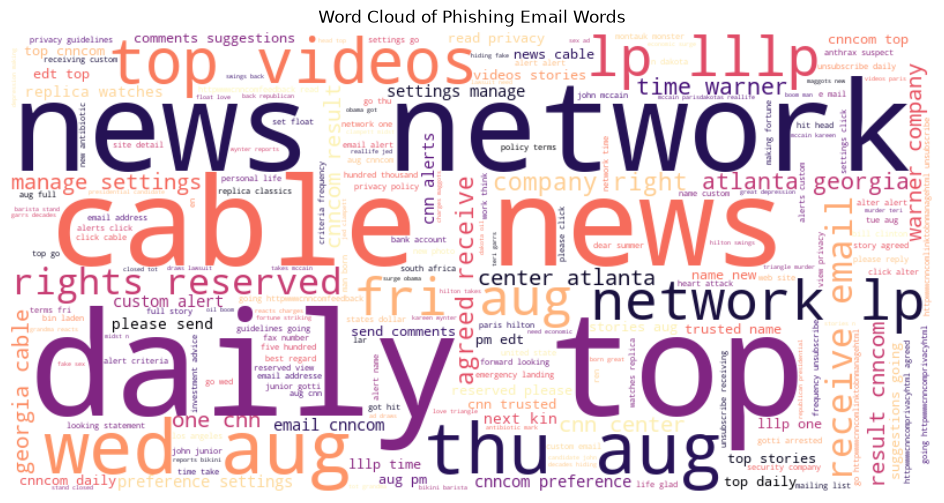

In [33]:
from wordcloud import WordCloud

# Join all filtered phishing words into a single string
wordcloud_text = ' '.join(filtered_words)

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='magma').generate(wordcloud_text)

# Display the word cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Phishing Email Words')
plt.show()


 ### Split the Dataset in training , validation and test

In [34]:
from sklearn.model_selection import train_test_split

# 1. First, split out 20% test data

train_val_texts, test_texts, train_val_labels, test_labels = train_test_split(df['text_combined'].tolist(), df['label'].tolist(), test_size=0.2, random_state=42, stratify=df['label'])

# 2. Then split remaining 80% into 70% train and 10% val

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_val_texts, train_val_labels,
    test_size=0.125,  # 10% of total = 12.5% of the remaining 80%
    random_state=42, stratify=train_val_labels
)


#### Tokenization using BERT Tokenizer

These encodings are the tokenized versions of your input texts, structured in a way that BERT can understand

In [35]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
MAX_LEN = 128

# Tokenize the datasets (truncate only; DataCollatorWithPadding pads each batch)
train_encodings = tokenizer(train_texts, truncation=True, max_length=MAX_LEN)
val_encodings = tokenizer(val_texts, truncation=True, max_length=MAX_LEN)


In [36]:
print(train_encodings['input_ids'][0])          # View input IDs of the first text
print(train_encodings['attention_mask'][0]) 

[101, 10424, 4115, 5602, 9808, 11057, 2290, 4160, 2278, 21693, 12502, 9006, 7886, 8889, 2581, 2745, 15231, 18617, 2626, 3154, 10447, 17330, 10447, 2130, 2391, 9841, 24274, 3332, 2723, 11673, 6081, 7123, 6919, 5478, 2240, 4356, 2553, 2825, 3357, 2232, 21981, 5757, 15476, 2263, 5709, 17465, 28154, 5890, 8889, 23961, 2140, 3617, 2694, 3737, 6335, 15916, 19595, 5772, 102]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


#### Convert to HuggingFace Dataset

A custom PyTorch dataset class for handling tokenized email text data and labels.

- **Inherits**: `torch.utils.data.Dataset`
- **Purpose**: Feeds input to Hugging Face `Trainer` in a structured format.

#### Methods:
- `__init__(self, encodings, labels)`
  - Stores tokenized input data (`encodings`) and labels.
- `__getitem__(self, idx)`
  - Returns the input tensors and label for a specific index.
  - Example output:
    ```python
    {
      'input_ids': tensor(...),
      'attention_mask': tensor(...),
      'labels': tensor(...)
    }
    ```
- `__len__(self)`
  - Returns the total number of samples.
 
    
 
#### Data input format for bert
- input_ids: Token IDs representing the input text.

- attention_mask: Binary mask to distinguish real tokens (1) from padding (0).

- labels: True class values used for supervised learning.

- [CLS]: Special token added at the start of input for classification tasks.

- [SEP]: Separator token marking the end of a sentence or segment.



In [37]:
class EmailDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
        
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = EmailDataset(train_encodings, train_labels)
val_dataset = EmailDataset(val_encodings, val_labels)


#### Load Pretrained BERT for Classification

In [38]:
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2, attn_implementation="eager")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


#### Define Evaluation Metrics

In [39]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }


#### Training Arguments

`TrainingArguments` is a configuration class that defines how your model should be trained. You pass it key training parameters such as:

- `output_dir`: Where to save model checkpoints.
- `learning_rate`: Controls how fast the model learns.
- `num_train_epochs`: Number of complete passes through the training data.
- `evaluation_strategy`: When to run validation (e.g., `"epoch"` means after every epoch).
- `per_device_train_batch_size`: Batch size per GPU/CPU device during training.
- `logging_dir`: Directory to store training logs.

It does **not** train the model — it only stores training settings that the `Trainer` will use.



In [44]:
training_args = TrainingArguments(
    output_dir='./results',
    eval_strategy="steps",             # Validate every eval_steps
    eval_steps=1000,
    save_strategy="steps",             # Checkpoint every save_steps (lets you resume)
    save_steps=1000,
    save_total_limit=2,                # Keep only last 2 checkpoints
    learning_rate=2e-5,
    warmup_steps=300,                  # gentle start, avoids early divergence
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    weight_decay=0.01,
    optim="adamw_torch",
    dataloader_pin_memory=False,       # pin_memory is not supported on Apple GPU
    logging_strategy="steps",          # Log training loss every 50 steps
    logging_steps=50,
    load_best_model_at_end=True,       # Load best val score model
    metric_for_best_model="f1",        # Based on compute_metrics
    greater_is_better=True             # Because higher F1 is better
)


#### Trainer




`Trainer` is the training engine provided by Hugging Face. It handles the full model training lifecycle. Specifically, it:

- Loads and trains your model.
- Handles batching, shuffling, and tokenization.
- Trains the model using PyTorch under the hood.
- Evaluates the model on your `eval_dataset`.
- Uses the settings defined in `TrainingArguments`.
- Automatically supports training on GPU or TPU if available.

`Trainer` simplifies the process so you don’t need to manually write training loops, backpropagation, or optimizer logic.

In [45]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics
)

#### Speed and NaN check (run before training)

Runs 6 forward/backward passes **without updating the weights**, prints the loss and seconds per step, and estimates the total training time. Loss should be a normal number (about 0.5-0.9), not `nan`. Also adds a guard that stops training automatically if the loss ever becomes `nan`.

In [46]:
import time, math
from torch.utils.data import DataLoader
from transformers import TrainerCallback

class StopOnNaN(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        loss = (logs or {}).get("loss")
        if loss is not None and (math.isnan(loss) or math.isinf(loss)):
            print(f"!!! Loss is {loss} at step {state.global_step}. Stopping training.")
            control.should_training_stop = True

trainer.add_callback(StopOnNaN())

dev = "mps" if torch.backends.mps.is_available() else "cpu"
print("Device:", dev)

model.to(dev).train()
loader = DataLoader(train_dataset, batch_size=16, shuffle=True,
                    collate_fn=DataCollatorWithPadding(tokenizer=tokenizer))
times = []
for i, batch in enumerate(loader):
    batch = {k: v.to(dev) for k, v in batch.items()}
    t0 = time.time()
    out = model(**batch)
    out.loss.backward()
    if dev == "mps":
        torch.mps.synchronize()
    times.append(time.time() - t0)
    print(f"step {i}: loss={out.loss.item():.4f}  time={times[-1]:.2f}s")
    model.zero_grad()
    if i == 5:
        break

sec_per_step = sum(times[1:]) / len(times[1:])   # skip the first (warm-up) step
total_steps = math.ceil(len(train_dataset) / 16) * training_args.num_train_epochs
print(f"\n~{sec_per_step:.2f}s/step, {total_steps} steps -> roughly {sec_per_step * total_steps * 1.15 / 3600:.1f} hours (incl. eval overhead)")

del loader, batch, out
if dev == "mps":
    torch.mps.empty_cache()


Device: mps
step 0: loss=0.8590  time=1.55s
step 1: loss=0.8571  time=0.83s
step 2: loss=0.7820  time=0.84s
step 3: loss=0.8464  time=0.82s
step 4: loss=0.7818  time=0.83s
step 5: loss=0.7871  time=0.82s

~0.83s/step, 17955 steps -> roughly 4.7 hours (incl. eval overhead)


#### Train the BERT Model

The `trainer.train()` method is the command that **starts the training process** using the configuration and datasets you’ve defined with Hugging Face’s `Trainer` class.

It does the following:

- Loads the `train_dataset` and batches the data.
- Feeds each batch through the model.
- Computes the loss and performs backpropagation to update model weights.
- Evaluates the model on the `eval_dataset` if `evaluation_strategy` is set (e.g., `"epoch"`).
- Saves checkpoints if `save_strategy` is configured.
- Logs training metrics (loss, accuracy, etc.) if `logging_dir` is specified.

##### What It Uses Internally:
- Model defined in `Trainer(model=...)`
- Training configuration from `TrainingArguments`
- Tokenizer and data collator for handling padding and batching
- Evaluation function if `compute_metrics` is provided

##### Output:
After running `trainer.train()`, the model will be:
- Trained on your training data
- Optionally validated each epoch
- Saved to the directory specified in `output_dir`


In [48]:
trainer.train()

Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1000,0.095113,0.069748,0.983674,0.984469,0.977895,0.991132
2000,0.092358,0.045825,0.988426,0.988939,0.986757,0.991132
3000,0.032210,0.038225,0.990010,0.990389,0.994820,0.985998
4000,0.020706,0.045916,0.989888,0.990259,0.995987,0.984597
5000,0.018363,0.047779,0.990984,0.991321,0.996463,0.986231
6000,0.027135,0.047255,0.989522,0.989897,0.996688,0.983197
7000,0.017188,0.042235,0.991715,0.992045,0.994605,0.989498
8000,0.006081,0.044091,0.992690,0.992979,0.995776,0.990198
9000,0.000074,0.078236,0.986720,0.987133,0.998806,0.975729
10000,0.001997,0.040461,0.993543,0.993795,0.997180,0.990432


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=17955, training_loss=0.018993948935332516, metrics={'train_runtime': 64129.794, 'train_samples_per_second': 4.48, 'train_steps_per_second': 0.28, 'total_flos': 1.890951199322688e+16, 'train_loss': 0.018993948935332516, 'epoch': 5.0})

## Plot Accuracy and Loss vs Epoch

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


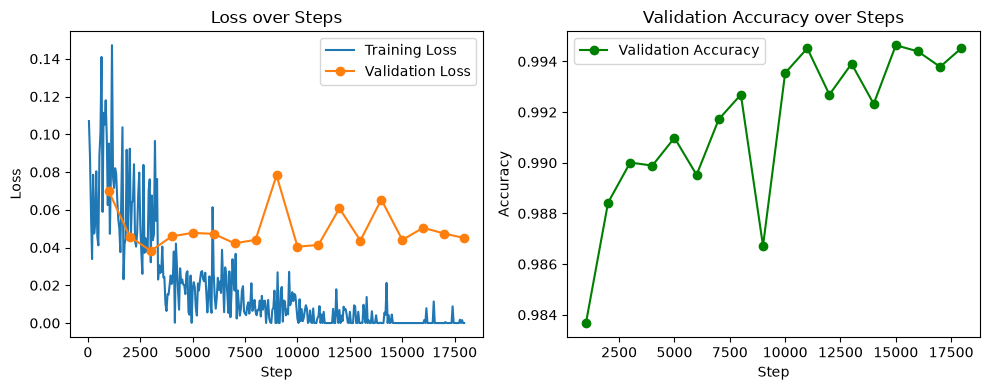

In [49]:
import matplotlib.pyplot as plt

# Extract logs
log_history = trainer.state.log_history

train_steps = [e['step'] for e in log_history if 'loss' in e]
train_loss  = [e['loss'] for e in log_history if 'loss' in e]
eval_steps  = [e['step'] for e in log_history if 'eval_loss' in e]
eval_loss   = [e['eval_loss'] for e in log_history if 'eval_loss' in e]
eval_acc    = [e['eval_accuracy'] for e in log_history if 'eval_accuracy' in e]

# Plot loss
plt.figure(figsize=(10,4))
plt.subplot(1, 2, 1)
plt.plot(train_steps, train_loss, label='Training Loss')
plt.plot(eval_steps, eval_loss, marker='o', label='Validation Loss')
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Loss over Steps")
plt.legend()

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(eval_steps, eval_acc, marker='o', color='green', label='Validation Accuracy')
plt.xlabel("Step")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy over Steps")
plt.legend()

plt.tight_layout()
plt.show()


## Save the Final Model & Tokenizer

In [50]:
# Save model and tokenizer
model.save_pretrained("./final_model")
tokenizer.save_pretrained("./final_model")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./final_model/tokenizer_config.json', './final_model/tokenizer.json')

In [51]:
from transformers import BertForSequenceClassification, BertTokenizer
model = BertForSequenceClassification.from_pretrained("./final_model")
tokenizer = BertTokenizer.from_pretrained("./final_model")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

### Test the model

##### Tokenize test data

In [52]:
test_encodings = tokenizer(test_texts, truncation=True, max_length=MAX_LEN)


#### Convert to PyTorch Dataset

In [53]:
test_dataset = EmailDataset(test_encodings, test_labels)

#### Evaluate Model on Test Set

In [54]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Run predictions on the test set
test_results = trainer.predict(test_dataset)

# Extract predicted class labels
y_pred = test_results.predictions.argmax(axis=1)
y_true = test_labels  # Make sure test_labels is a list of integers

# Print all core metrics
print("Final Test Evaluation Metrics:\n")
print("Accuracy       :", accuracy_score(y_true, y_pred))
print("Precision      :", precision_score(y_true, y_pred))
print("Recall         :", recall_score(y_true, y_pred))
print("F1 Score       :", f1_score(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=["Legitimate", "Phishing"]))



Final Test Evaluation Metrics:

Accuracy       : 0.9947002923976608
Precision      : 0.994173852248893
Recall         : 0.9956821099311471
F1 Score       : 0.9949274094804967

Classification Report:
               precision    recall  f1-score   support

  Legitimate       1.00      0.99      0.99      7847
    Phishing       0.99      1.00      0.99      8569

    accuracy                           0.99     16416
   macro avg       0.99      0.99      0.99     16416
weighted avg       0.99      0.99      0.99     16416



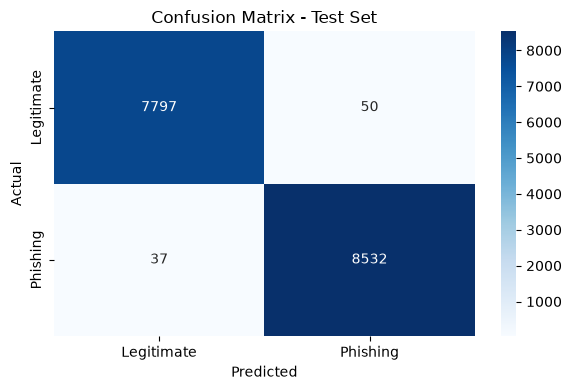

In [55]:
# Plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legitimate', 'Phishing'], yticklabels=['Legitimate', 'Phishing'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Test Set')
plt.tight_layout()
plt.show()


In [56]:
from sklearn.metrics import classification_report

y_pred = test_results.predictions.argmax(axis=1)
print(classification_report(test_labels, y_pred, target_names=["Legitimate", "Phishing"]))


              precision    recall  f1-score   support

  Legitimate       1.00      0.99      0.99      7847
    Phishing       0.99      1.00      0.99      8569

    accuracy                           0.99     16416
   macro avg       0.99      0.99      0.99     16416
weighted avg       0.99      0.99      0.99     16416



In [57]:
import json, pandas as pd
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments

# 1. Save the training log (for the paper's curves/tables)
json.dump(trainer.state.log_history, open("log_history.json", "w"))
print("best checkpoint:", trainer.state.best_model_checkpoint)

# 2. Evaluate the properly loaded best checkpoint on the test set
best_model = AutoModelForSequenceClassification.from_pretrained(trainer.state.best_model_checkpoint)
eval_trainer = Trainer(
    model=best_model,
    args=TrainingArguments(output_dir="./eval_tmp", per_device_eval_batch_size=32,
                           report_to="none", dataloader_pin_memory=False),
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
)
best_pred = eval_trainer.predict(test_dataset).predictions.argmax(-1)
print("best checkpoint -> acc, F1:", accuracy_score(test_labels, best_pred), f1_score(test_labels, best_pred))
print("current model   -> acc, F1:", accuracy_score(test_labels, y_pred), f1_score(test_labels, y_pred))

# 3. Misclassified emails, for error analysis
test_df = pd.DataFrame({"text": test_texts, "true": test_labels, "pred": best_pred})
errors = test_df[test_df.true != test_df.pred]
errors.to_csv("test_errors.csv", index=False)
print(errors.groupby(["true", "pred"]).size())

best checkpoint: ./results/checkpoint-15000


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

best checkpoint -> acc, F1: 0.9947002923976608 0.9949274094804967
current model   -> acc, F1: 0.9947002923976608 0.9949274094804967
true  pred
0     1       50
1     0       37
dtype: int64


In [58]:
   from sklearn.feature_extraction.text import TfidfVectorizer
   from sklearn.linear_model import LogisticRegression

   vec = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), sublinear_tf=True)
   lr = LogisticRegression(max_iter=1000).fit(vec.fit_transform(train_texts), train_labels)
   base_pred = lr.predict(vec.transform(test_texts))

   print(classification_report(test_labels, base_pred, target_names=["Legitimate", "Phishing"], digits=4))
   print(confusion_matrix(test_labels, base_pred))

              precision    recall  f1-score   support

  Legitimate     0.9894    0.9838    0.9866      7847
    Phishing     0.9853    0.9903    0.9878      8569

    accuracy                         0.9872     16416
   macro avg     0.9873    0.9871    0.9872     16416
weighted avg     0.9872    0.9872    0.9872     16416

[[7720  127]
 [  83 8486]]
